# 05 – Model Evaluation
**AlchemiX – Launch26 Phase 2**

## Objectives
1. Load trained models and test data
2. Regression: MAE, RMSE, R², MAPE + residual analysis + learning curve
3. Classification: Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix
4. Feature importance for all three models
5. Generate a professional evaluation report

In [1]:
import sys, pathlib, json
PROJECT_ROOT = pathlib.Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

# sklearn.metrics — RocCurveDisplay and PrecisionRecallDisplay live here
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
# CalibrationDisplay moved to sklearn.calibration in sklearn 1.2+
from sklearn.calibration import CalibrationDisplay

from ml.utils import (
    TRAFFIC_ENG_FILE, TELEMETRY_ENG_FILE, INCIDENT_ENG_FILE,
    CONGESTION_MODEL_FILE, TRUST_MODEL_FILE, TARGETING_MODEL_FILE,
    MODELS_DIR, RANDOM_SEED,
)
from ml.training import (
    split_data,
    add_historical_features_traffic,
    add_historical_features_telemetry,
    add_historical_features_incident,
    build_preprocessor,
)
from ml.evaluation import (
    regression_metrics, classification_metrics,
    plot_residuals, plot_confusion_matrix,
    plot_feature_importance, plot_learning_curve,
    plot_pred_vs_actual,
)

print('Imports OK ✓')

Imports OK ✓


In [2]:
meta = json.loads((MODELS_DIR / 'model_metadata.json').read_text())

congestion_model  = joblib.load(CONGESTION_MODEL_FILE)
trust_model       = joblib.load(TRUST_MODEL_FILE)
targeting_model   = joblib.load(TARGETING_MODEL_FILE)
preprocessor_t    = joblib.load(MODELS_DIR / 'preprocessor_congestion.joblib')
preprocessor_te   = joblib.load(MODELS_DIR / 'preprocessor_trust.joblib')
preprocessor_i    = joblib.load(MODELS_DIR / 'preprocessor_targeting.joblib')

print('Models loaded ✓')
print(f'  Congestion : {type(congestion_model).__name__}')
print(f'  Trust      : {type(trust_model).__name__}')
print(f'  Targeting  : {type(targeting_model).__name__}')

Models loaded ✓
  Congestion : XGBRegressor
  Trust      : LGBMRegressor
  Targeting  : DecisionTreeClassifier


## 1. Rebuild Test Sets (same split as Notebook 04)

In [3]:
# ── Traffic ───────────────────────────────────────────────────────────────────
traffic_eng   = pd.read_csv(TRAFFIC_ENG_FILE)
train_t, test_t = split_data(traffic_eng, 'observed_latency_ms')
train_t, test_t = add_historical_features_traffic(train_t, test_t)
TRAFFIC_NUMERIC     = meta['congestion']['numeric']
TRAFFIC_CATEGORICAL = meta['congestion']['categorical']
X_test_t = preprocessor_t.transform(test_t[TRAFFIC_NUMERIC + TRAFFIC_CATEGORICAL])
y_test_t = test_t['observed_latency_ms'].values

# ── Telemetry ─────────────────────────────────────────────────────────────────
telemetry_eng = pd.read_csv(TELEMETRY_ENG_FILE)
train_te, test_te = split_data(telemetry_eng, 'trust_score')
train_te, test_te = add_historical_features_telemetry(train_te, test_te)
TELE_NUMERIC     = meta['trust']['numeric']
TELE_CATEGORICAL = meta['trust']['categorical']
X_test_te = preprocessor_te.transform(test_te[TELE_NUMERIC + TELE_CATEGORICAL])
y_test_te = test_te['trust_score'].values

# ── Incident ──────────────────────────────────────────────────────────────────
incident_eng  = pd.read_csv(INCIDENT_ENG_FILE)
incident_eng['jammed_flag'] = incident_eng['jammed_flag'].astype(int)
train_i, test_i = split_data(incident_eng, 'jammed_flag', stratify_col='jammed_flag')
train_i, test_i = add_historical_features_incident(train_i, test_i)
INC_NUMERIC     = meta['targeting']['numeric']
INC_CATEGORICAL = meta['targeting']['categorical']
X_test_i = preprocessor_i.transform(test_i[INC_NUMERIC + INC_CATEGORICAL])
y_test_i = test_i['jammed_flag'].values

print('Test sets rebuilt ✓')
print(f'  Traffic  test: {len(y_test_t)} rows')
print(f'  Telemetry test: {len(y_test_te)} rows')
print(f'  Incident  test: {len(y_test_i)} rows  (jam rate={y_test_i.mean():.3f})')

03:34:36  INFO      ml.training  split_data: train=4594  test=1149  target='observed_latency_ms'
03:34:36  INFO      ml.training  add_historical_features_traffic: added 3 historical columns
03:34:36  INFO      ml.training  split_data: train=4800  test=1200  target='trust_score'
03:34:36  INFO      ml.training  add_historical_features_telemetry: added 3 historical columns
03:34:36  INFO      ml.training  split_data: train=4800  test=1200  target='jammed_flag'
03:34:36  INFO      ml.training  add_historical_features_incident: added 1 historical column


Test sets rebuilt ✓
  Traffic  test: 1149 rows
  Telemetry test: 1200 rows
  Incident  test: 1200 rows  (jam rate=0.083)


---
## ① Congestion Model Evaluation

In [4]:
y_pred_t = congestion_model.predict(X_test_t)
print('Congestion Model – Test Metrics')
print('─' * 50)
m = regression_metrics(y_test_t, y_pred_t)
display(pd.DataFrame([m]))

03:34:36  INFO      ml.evaluation    MAE        = 13870.0540
03:34:36  INFO      ml.evaluation    RMSE       = 54646.3550
03:34:36  INFO      ml.evaluation    R2         = 0.8917
03:34:36  INFO      ml.evaluation    MAPE_%     = 8.1580


Congestion Model – Test Metrics
──────────────────────────────────────────────────


,MAE,RMSE,R2,MAPE_%
0,13870.054016,54646.354997,0.89168,8.15796


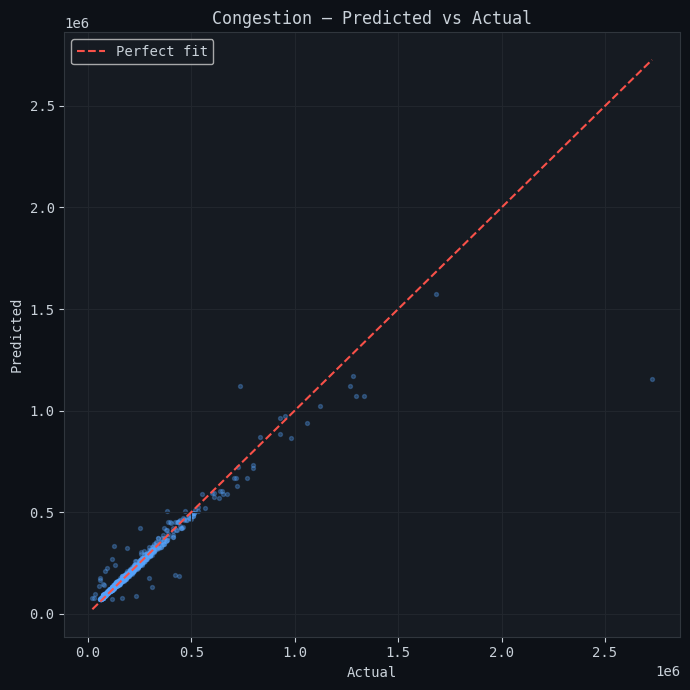

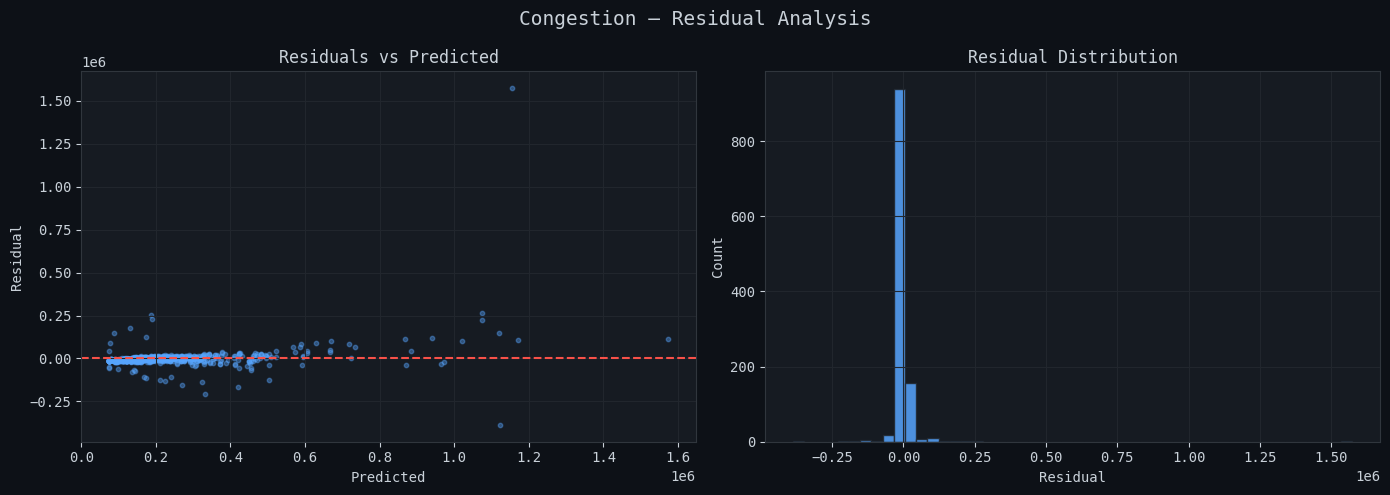

In [5]:
fig = plot_pred_vs_actual(y_test_t, y_pred_t, 'Congestion – Predicted vs Actual')
plt.show()
fig = plot_residuals(y_test_t, y_pred_t, 'Congestion – Residual Analysis')
plt.show()

Feature importance not available: list index out of range


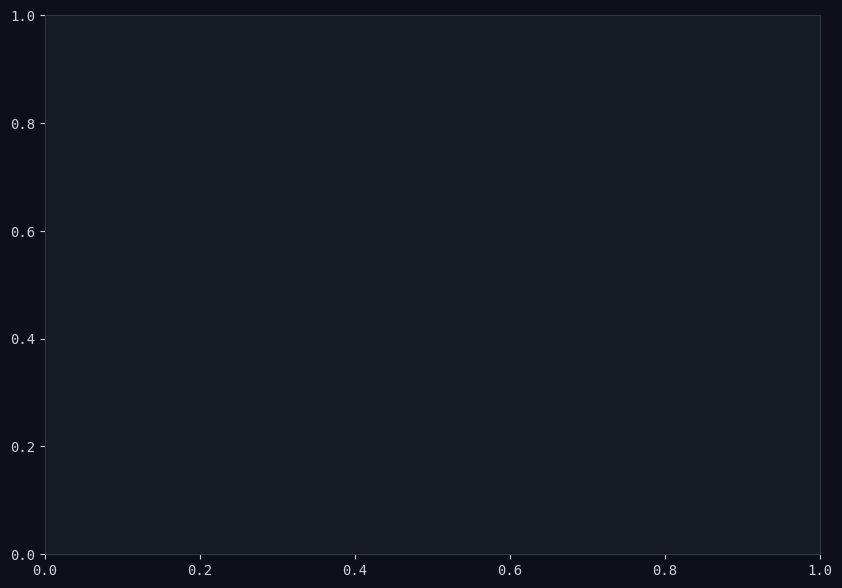

In [6]:
try:
    fig = plot_feature_importance(
        congestion_model, TRAFFIC_NUMERIC,
        title='Congestion – Feature Importance'
    )
    plt.show()
except Exception as e:
    print(f'Feature importance not available: {e}')

---
## ② Trust Model Evaluation

03:34:37  INFO      ml.evaluation    MAE        = 0.0003
03:34:37  INFO      ml.evaluation    RMSE       = 0.0009
03:34:37  INFO      ml.evaluation    R2         = 0.9999
03:34:37  INFO      ml.evaluation    MAPE_%     = 0.0363


Trust Model – Test Metrics
──────────────────────────────────────────────────


,MAE,RMSE,R2,MAPE_%
0,0.000274,0.000911,0.999917,0.036331


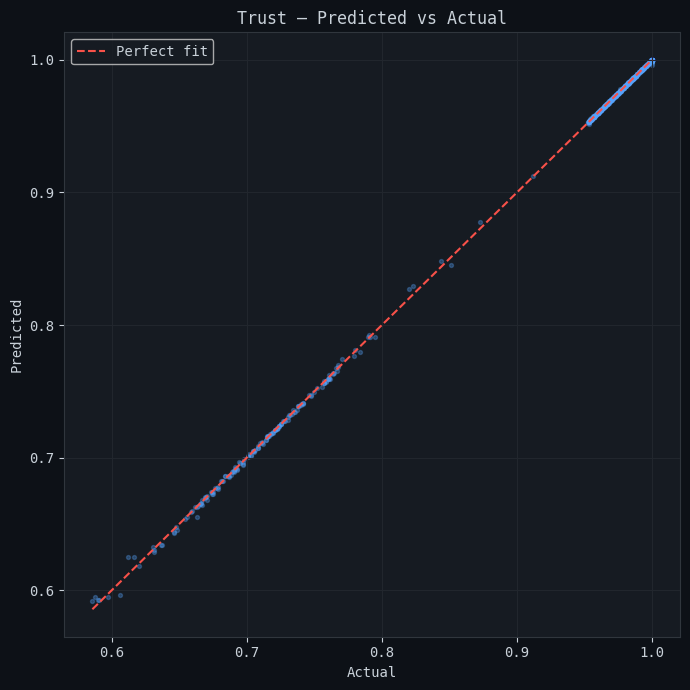

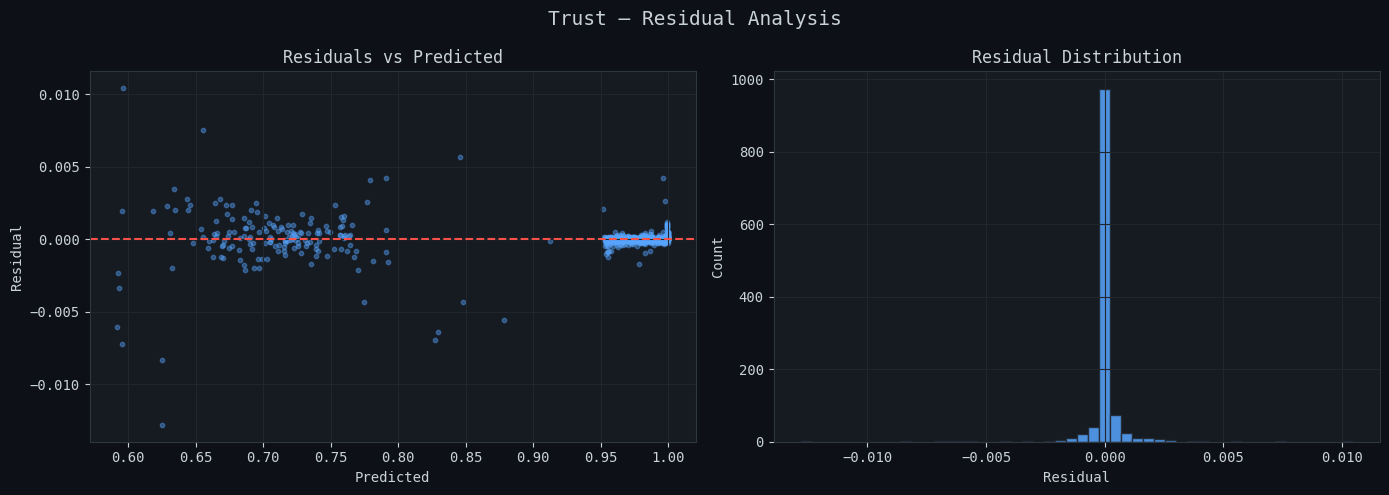

In [7]:
y_pred_te = trust_model.predict(X_test_te)
y_pred_te = np.clip(y_pred_te, 0, 1)  # trust is in [0,1]
print('Trust Model – Test Metrics')
print('─' * 50)
m = regression_metrics(y_test_te, y_pred_te)
display(pd.DataFrame([m]))

fig = plot_pred_vs_actual(y_test_te, y_pred_te, 'Trust – Predicted vs Actual')
plt.show()
fig = plot_residuals(y_test_te, y_pred_te, 'Trust – Residual Analysis')
plt.show()

Feature importance not available: list index out of range


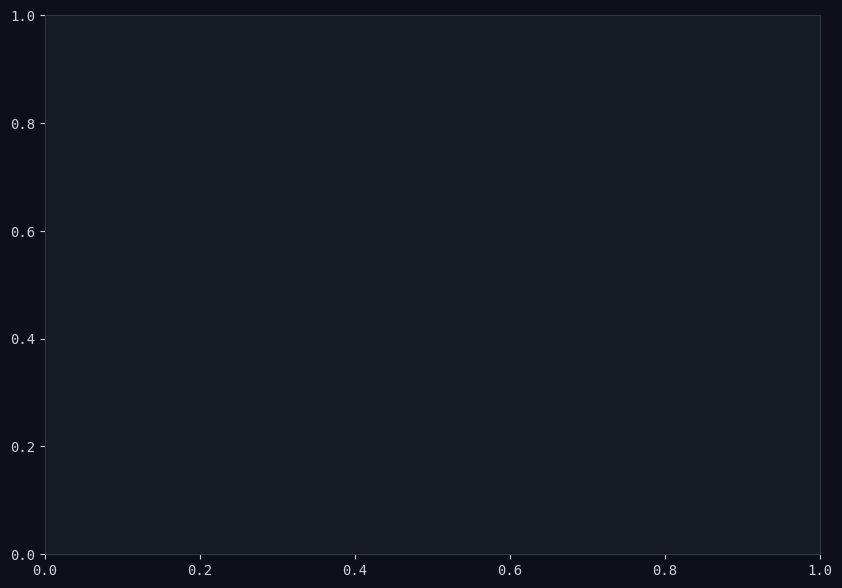

In [8]:
try:
    fig = plot_feature_importance(
        trust_model, TELE_NUMERIC,
        title='Trust – Feature Importance'
    )
    plt.show()
except Exception as e:
    print(f'Feature importance not available: {e}')

---
## ③ Targeting Model Evaluation

In [9]:
y_pred_i = targeting_model.predict(X_test_i)
y_prob_i = targeting_model.predict_proba(X_test_i)[:, 1]
print('Targeting Model – Test Metrics')
print('─' * 50)
m = classification_metrics(y_test_i, y_pred_i, y_prob_i)
display(pd.DataFrame([m]))

03:34:37  INFO      ml.evaluation    Accuracy     = 0.9133
03:34:37  INFO      ml.evaluation    Precision    = 0.0000
03:34:37  INFO      ml.evaluation    Recall       = 0.0000
03:34:37  INFO      ml.evaluation    F1           = 0.0000
03:34:37  INFO      ml.evaluation    ROC_AUC      = 0.5847


Targeting Model – Test Metrics
──────────────────────────────────────────────────


,Accuracy,Precision,Recall,F1,ROC_AUC
0,0.913333,0.0,0.0,0.0,0.58468


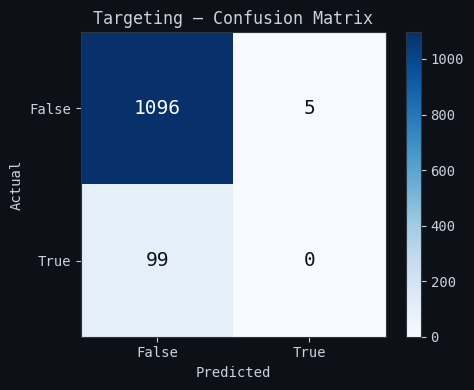

In [10]:
fig = plot_confusion_matrix(y_test_i, y_pred_i, 'Targeting – Confusion Matrix')
plt.show()

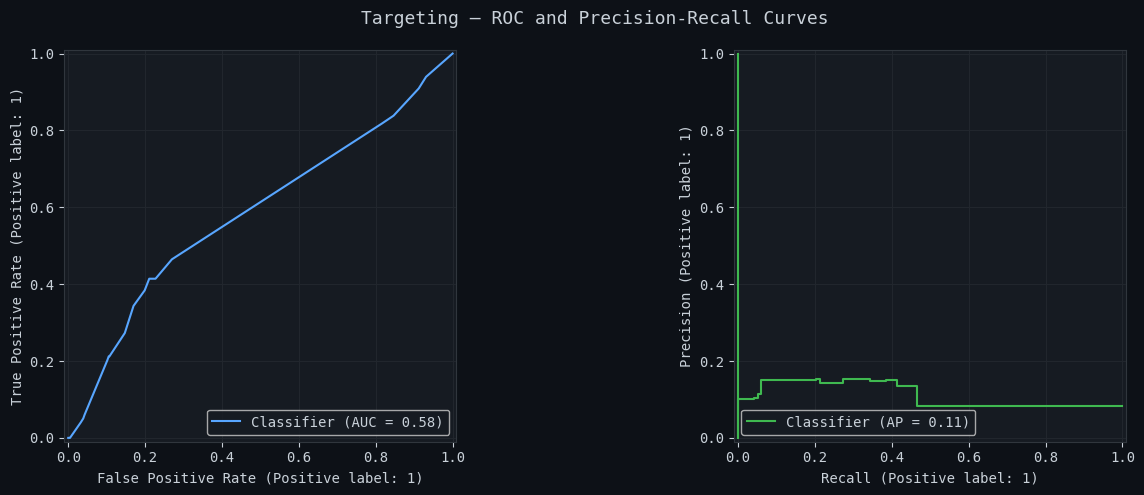

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Targeting – ROC and Precision-Recall Curves', fontsize=13)
RocCurveDisplay.from_predictions(y_test_i, y_prob_i, ax=axes[0], color='#58a6ff')
PrecisionRecallDisplay.from_predictions(y_test_i, y_prob_i, ax=axes[1], color='#3fb950')
for ax in axes:
    ax.grid(True)
plt.tight_layout()
plt.show()

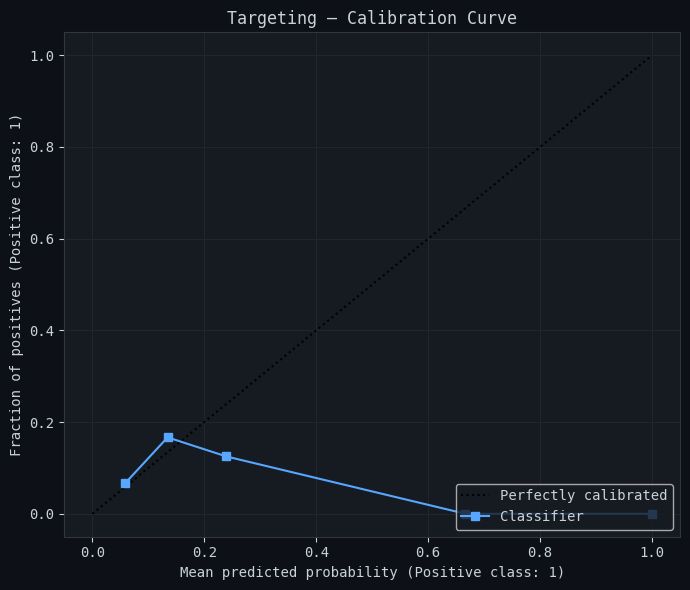

In [12]:
fig, ax = plt.subplots(figsize=(7, 6))
CalibrationDisplay.from_predictions(y_test_i, y_prob_i, n_bins=10, ax=ax, color='#58a6ff')
ax.set_title('Targeting – Calibration Curve')
ax.grid(True)
plt.tight_layout()
plt.show()

Feature importance not available: list index out of range


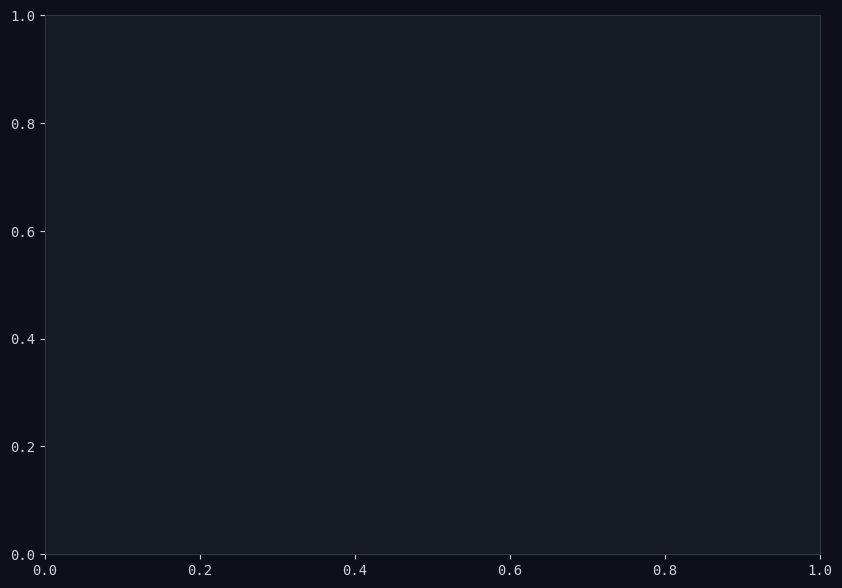

In [13]:
try:
    fig = plot_feature_importance(
        targeting_model, INC_NUMERIC,
        title='Targeting – Feature Importance'
    )
    plt.show()
except Exception as e:
    print(f'Feature importance not available: {e}')

## Evaluation Summary

In [14]:
import warnings; warnings.filterwarnings('ignore')

m_cong   = regression_metrics(y_test_t, congestion_model.predict(X_test_t))
m_trust  = regression_metrics(y_test_te, np.clip(trust_model.predict(X_test_te), 0, 1))
m_target = classification_metrics(
    y_test_i,
    targeting_model.predict(X_test_i),
    targeting_model.predict_proba(X_test_i)[:, 1]
)

summary = pd.DataFrame({
    'Model':  ['Congestion', 'Trust', 'Targeting'],
    'Task':   ['Regression', 'Regression', 'Classification'],
    'MAE / Accuracy': [
        f"{m_cong['MAE']:.2f} ms",
        f"{m_trust['MAE']:.4f}",
        f"{m_target['Accuracy']:.4f}"
    ],
    'RMSE / F1': [
        f"{m_cong['RMSE']:.2f} ms",
        f"{m_trust['RMSE']:.4f}",
        f"{m_target['F1']:.4f}"
    ],
    'R² / ROC-AUC': [
        f"{m_cong['R2']:.4f}",
        f"{m_trust['R2']:.4f}",
        f"{m_target.get('ROC_AUC', 'N/A')}"
    ],
})
display(summary)
print('\n✓ Notebook 05 complete – proceed to Notebook 06 Model Export.')

03:34:38  INFO      ml.evaluation    MAE        = 13870.0540
03:34:38  INFO      ml.evaluation    RMSE       = 54646.3550
03:34:38  INFO      ml.evaluation    R2         = 0.8917
03:34:38  INFO      ml.evaluation    MAPE_%     = 8.1580
03:34:38  INFO      ml.evaluation    MAE        = 0.0003
03:34:38  INFO      ml.evaluation    RMSE       = 0.0009
03:34:38  INFO      ml.evaluation    R2         = 0.9999
03:34:38  INFO      ml.evaluation    MAPE_%     = 0.0363
03:34:38  INFO      ml.evaluation    Accuracy     = 0.9133
03:34:38  INFO      ml.evaluation    Precision    = 0.0000
03:34:38  INFO      ml.evaluation    Recall       = 0.0000
03:34:38  INFO      ml.evaluation    F1           = 0.0000
03:34:38  INFO      ml.evaluation    ROC_AUC      = 0.5847


,Model,Task,MAE / Accuracy,RMSE / F1,R² / ROC-AUC
0,Congestion,Regression,13870.05 ms,54646.35 ms,0.8917
1,Trust,Regression,0.0003,0.0009,0.9999
2,Targeting,Classification,0.9133,0.0000,0.5846796759603299



✓ Notebook 05 complete – proceed to Notebook 06 Model Export.
